Download Libraries

In [ ]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

from catboost import CatBoostClassifier

Upload File

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_dataset00.csv to diabetes_dataset00.csv


Load Dataset

In [ ]:
df = pd.read_csv("diabetes_dataset00.csv")
df.head()

,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,76,No,No,Positive,3,Normal,56,Ketones Present,2629,No
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,60,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,80,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,89,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,41,No,No,Positive,1,Normal,24,Protein Present,1770,No


Separate Target Variable

In [ ]:
target_column = "Target"

X = df.drop(columns=[target_column])
y = df[target_column]

Identify Numerical & Categorical Columns

In [ ]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", numerical_cols)
print("Categorical Features:", categorical_cols)

Numerical Features: ['Insulin Levels', 'Age', 'BMI', 'Blood Pressure', 'Cholesterol Levels', 'Waist Circumference', 'Blood Glucose Levels', 'Weight Gain During Pregnancy', 'Pancreatic Health', 'Pulmonary Function', 'Neurological Assessments', 'Digestive Enzyme Levels', 'Birth Weight']
Categorical Features: ['Genetic Markers', 'Autoantibodies', 'Family History', 'Environmental Factors', 'Physical Activity', 'Dietary Habits', 'Ethnicity', 'Socioeconomic Factors', 'Smoking Status', 'Alcohol Consumption', 'Glucose Tolerance Test', 'History of PCOS', 'Previous Gestational Diabetes', 'Pregnancy History', 'Cystic Fibrosis Diagnosis', 'Steroid Use History', 'Genetic Testing', 'Liver Function Tests', 'Urine Test', 'Early Onset Symptoms']


Identify Feature Groups

In [ ]:
# Target
target = "Target"

# Numerical columns
num_features = [
    "Insulin Levels","Age","BMI","Blood Pressure","Cholesterol Levels",
    "Waist Circumference","Blood Glucose Levels","Weight Gain During Pregnancy",
    "Pancreatic Health","Pulmonary Function","Neurological Assessments",
    "Digestive Enzyme Levels","Birth Weight"
]

# Categorical columns
cat_features = [col for col in df.columns if col not in num_features + [target]]

Encode Target Variable (Multi-Class)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Target_encoded"] = le.fit_transform(df["Target"])

**Build Preprocessing Pipeline**

Numerical Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

Categorical Pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

Combine with ColumnTransformer

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

**Stratified Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(["Target","Target_encoded"], axis=1)
y = df["Target_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

**Fit Preprocessing Pipeline**

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

**Logistic Regression (Baseline Model)**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, multi_class="ovr"))
])

# Train
log_reg_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = log_reg_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Evaluation Metrics (Accuracy + Macro F1)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import precision_score, recall_score

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="macro")
precision_lr = precision_score(y_test, y_pred_lr, average="macro")
recall_lr = recall_score(y_test, y_pred_lr, average="macro")



print("Logistic Regression Accuracy:", acc_lr)
print("Logistic Regression Macro F1:", f1_lr)
print("Logistic Regression Precision:", precision_lr)
print("Logistic Regression Recall:", recall_lr)

Logistic Regression Accuracy: 0.7110714285714286
Logistic Regression Macro F1: 0.7087228906390808
Logistic Regression Precision: 0.7089833467548287
Logistic Regression Recall: 0.7110577349172907


Confusion Matrix

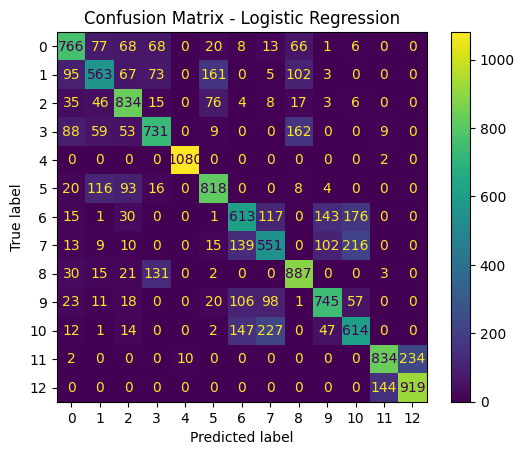

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Save Baseline Results**

In [ ]:
results = {
    "Logistic Regression": {"Accuracy": acc_lr, "Macro F1": f1_lr}
}

# Hyperparameter-Tuned Models:

Random Forest

XGBoost

CatBoost

Neural Network (MLP)

Stratified Cross-Validation Setup

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

**MODEL 1 — RANDOM FOREST (TUNED)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Insulin '
                                                                          'Levels',
                                                                          'Age',
                                                                          'BMI',
                                                                          'Blood '
                                                                          'Pressure',
                                                                          'Cholesterol '
                                                                          'Levels',
                                                                          'Waist '
                                                                          'Circumference',
                                                                          'Blood '
                                                                          'Glucose '
                                                                          'Levels',
                                                                          'Weight '
                                                                          'Gain '
                                                                          'During '
                                                                          'Pregnanc...
                                                                          'Testing',
                                                                          'Liver '
                                                                          'Function '
                                                                          'Tests',
                                                                          'Urine '
                                                                          'Test',
                                                                          'Early '
                                                                          'Onset '
                                                                          'Symptoms'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [200, 500]},
             scoring='f1_macro', verbose=2)

Evaluate Best RF

In [88]:
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="macro")
precision_rf = precision_score(y_test, y_pred_rf, average="macro")
recall_rf = recall_score(y_test, y_pred_rf, average="macro")

print("Random Forest Accuracy:", acc_rf)
print("Random Forest Macro F1:", f1_rf)
print("Random Forest Precision:", precision_rf)
print("Random Forest Recall:", recall_rf)

results["Random Forest"] = {"Accuracy": acc_rf, "Macro F1": f1_rf, "Precision":precision_rf, "Recall":recall_rf}

Random Forest Accuracy: 0.9004285714285715
Random Forest Macro F1: 0.8994280877991526
Random Forest Precision: 0.9051421338405388
Random Forest Recall: 0.9008403531762418


**MODEL 2 — XGBOOST**

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [4, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1],
    "model__colsample_bytree": [0.8, 1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Insulin '
                                                                          'Levels',
                                                                          'Age',
                                                                          'BMI',
                                                                          'Blood '
                                                                          'Pressure',
                                                                          'Cholesterol '
                                                                          'Levels',
                                                                          'Waist '
                                                                          'Circumference',
                                                                          'Blood '
                                                                          'Glucose '
                                                                          'Levels',
                                                                          'Weight '
                                                                          'Gain '
                                                                          'During '
                                                                          'Pregnanc...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None, num_class=13, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1],
                         'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [4, 8],
                         'model__n_estimators': [300, 500],
                         'model__subsample': [0.8, 1]},
             scoring='f1_macro', verbose=2)

Evaluate XGB

In [87]:
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
precision_xgb = precision_score(y_test, y_pred_xgb, average="macro")
recall_xgb = recall_score(y_test, y_pred_xgb, average="macro")

print("XGBOOST Accuracy:", acc_xgb)
print("XGBOOST F1:", f1_xgb)
print("XGBOOST Precision:", precision_xgb)
print("XGBOOST Recall:", recall_xgb)

results["XGBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Macro F1": f1_score(y_test, y_pred_xgb, average="macro"),
    "Precision": precision_score(y_test, y_pred_xgb, average="macro"),
    "Recall": recall_score(y_test, y_pred_xgb, average="macro")
}

XGBOOST Accuracy: 0.9082857142857143
XGBOOST F1: 0.9071687404956713
XGBOOST Precision: 0.9166710147344165
XGBOOST Recall: 0.9087277535188806


**MODEL 3 — CATBOOST**

In [ ]:
from catboost import CatBoostClassifier

cat_features_indices = [X.columns.get_loc(col) for col in cat_features]

cat_model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train, y_train, cat_features=cat_features_indices)

0:	learn: 2.3227086	total: 5.56s	remaining: 46m 13s
100:	learn: 0.3945609	total: 8m 11s	remaining: 32m 22s
200:	learn: 0.2863315	total: 16m 28s	remaining: 24m 29s
300:	learn: 0.2470664	total: 25m	remaining: 16m 32s
400:	learn: 0.2259044	total: 34m 6s	remaining: 8m 25s
499:	learn: 0.2116626	total: 43m 12s	remaining: 0us


CatBoostClassifier(depth=8, iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

Evaluate CatBoost

In [86]:
y_pred_cat = cat_model.predict(X_test)

acc_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat, average="macro")
precision_cat = precision_score(y_test, y_pred_cat, average="macro")
recall_cat = recall_score(y_test, y_pred_cat, average="macro")

print("CatBoost Accuracy:", acc_cat)
print("CatBoost F1 Score (Macro):", f1_cat)
print("CatBoost Precision (Macro):", precision_cat)
print("CatBoost Recall (Macro):", recall_cat)

results["CatBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_cat),
    "Macro F1": f1_score(y_test, y_pred_cat, average="macro"),
    "Precision": precision_score(y_test, y_pred_cat, average="macro"),
    "Recall": recall_score(y_test, y_pred_cat, average="macro")
}

CatBoost Accuracy: 0.9014285714285715
CatBoost F1 Score (Macro): 0.900467808538419
CatBoost Precision (Macro): 0.9051927728538364
CatBoost Recall (Macro): 0.901752807994973


**MODEL 4 — NEURAL NETWORK**

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(max_iter=300))
])

mlp_params = {
    "model__hidden_layer_sizes": [(128,), (128,64)],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    mlp_pipeline,
    mlp_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

mlp_grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Insulin '
                                                                          'Levels',
                                                                          'Age',
                                                                          'BMI',
                                                                          'Blood '
                                                                          'Pressure',
                                                                          'Cholesterol '
                                                                          'Levels',
                                                                          'Waist '
                                                                          'Circumference',
                                                                          'Blood '
                                                                          'Glucose '
                                                                          'Levels',
                                                                          'Weight '
                                                                          'Gain '
                                                                          'During '
                                                                          'Pregnanc...
                                                                          'Cystic '
                                                                          'Fibrosis '
                                                                          'Diagnosis',
                                                                          'Steroid '
                                                                          'Use '
                                                                          'History',
                                                                          'Genetic '
                                                                          'Testing',
                                                                          'Liver '
                                                                          'Function '
                                                                          'Tests',
                                                                          'Urine '
                                                                          'Test',
                                                                          'Early '
                                                                          'Onset '
                                                                          'Symptoms'])])),
                                       ('model', MLPClassifier(max_iter=300))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.0001, 0.001],
                         'model__hidden_layer_sizes': [(128,), (128, 64)],
                         'model__learning_rate_init': [0.001, 0.01]},
             scoring='f1_macro', verbose=2)

Evaluate MLP

In [81]:
mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average="macro")
precision_mlp = precision_score(y_test, y_pred_mlp, average="macro")
recall_mlp = recall_score(y_test, y_pred_mlp, average="macro")

print("Neural Network Accuracy:", acc_mlp)
print("Neural Network F1 Score (Macro):", f1_mlp)
print("Neural Network Precision (Macro):", precision_mlp)
print("Neural Network Recall (Macro):", recall_mlp)

results["MLP"] = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Macro F1": f1_score(y_test, y_pred_mlp, average="macro"),
    "Precision": precision_score(y_test, y_pred_mlp, average="macro"),
    "Recall": recall_score(y_test, y_pred_mlp, average="macro")
}

Neural Network Accuracy: 0.8566428571428572
Neural Network F1 Score (Macro): 0.8559337801682686
Neural Network Precision (Macro): 0.8581374200394312
Neural Network Recall (Macro): 0.8566322193730147


# Model Comparison Table

In [89]:
import pandas as pd
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Macro F1,Precision,Recall
MLP,0.856643,0.855934,0.858137,0.856632
Voting Ensemble,0.893714,0.892720,0.895039,0.894069
Stacking Ensemble,0.905071,0.904116,0.908809,0.905499
CatBoost,0.901429,0.900468,0.905193,0.901753
XGBoost,0.908286,0.907169,0.916671,0.908728
Random Forest,0.900429,0.899428,0.905142,0.900840


# **ENSEMBLE LEARNING**

**VOTING CLASSIFIER**

Build Voting Ensemble Pipeline

In [82]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("lr", log_reg_pipeline),
        ("rf", rf_best),
        ("xgb", xgb_best),
        ("mlp", mlp_best)
    ],
    voting="soft"
)

voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)

results["Voting Ensemble"] = {
    "Accuracy": accuracy_score(y_test, y_pred_vote),
    "Macro F1": f1_score(y_test, y_pred_vote, average="macro"),
    "Precision": precision_score(y_test, y_pred_vote, average="macro"),
    "Recall": recall_score(y_test, y_pred_vote, average="macro")
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


**STACKING MODEL**

Build Stacking Classifier

In [83]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=[
        ("rf", rf_best),
        ("xgb", xgb_best),
        ("mlp", mlp_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)

results["Stacking Ensemble"] = {
    "Accuracy": accuracy_score(y_test, y_pred_stack),
    "Macro F1": f1_score(y_test, y_pred_stack, average="macro"),
    "Precision": precision_score(y_test, y_pred_stack, average="macro"),
    "Recall": recall_score(y_test, y_pred_stack, average="macro")
}

# **FINAL RESULTS TABLE**

In [90]:
results_df = pd.DataFrame(results).T.sort_values("Macro F1", ascending=False)
results_df

,Accuracy,Macro F1,Precision,Recall
XGBoost,0.908286,0.907169,0.916671,0.908728
Stacking Ensemble,0.905071,0.904116,0.908809,0.905499
CatBoost,0.901429,0.900468,0.905193,0.901753
Random Forest,0.900429,0.899428,0.905142,0.900840
Voting Ensemble,0.893714,0.892720,0.895039,0.894069
MLP,0.856643,0.855934,0.858137,0.856632


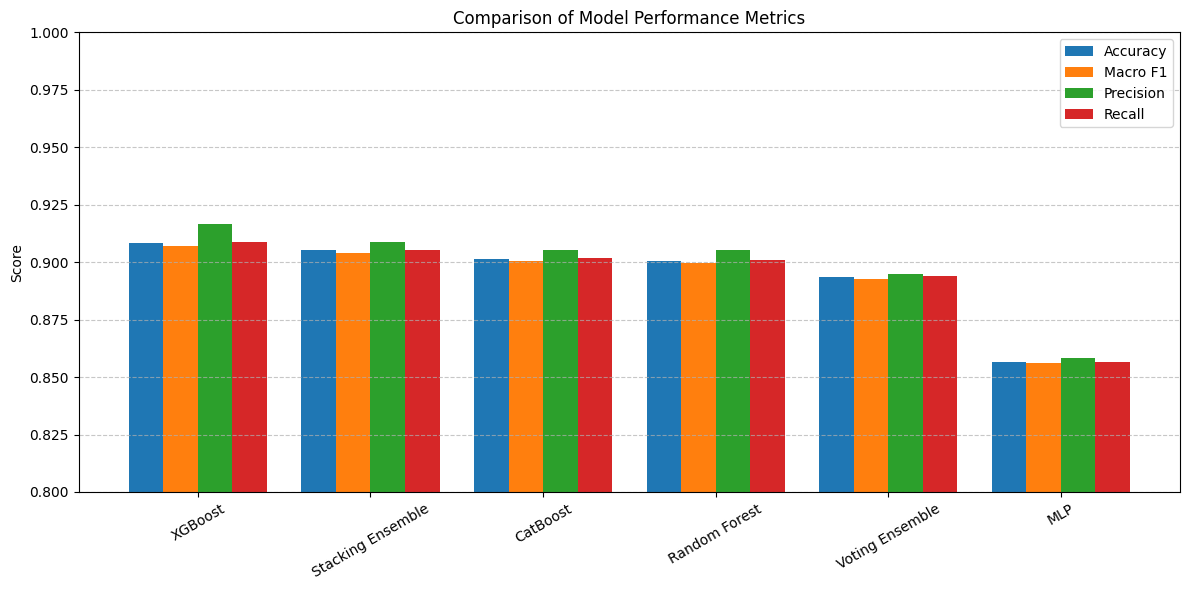

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Create DataFrame with your results
# -----------------------------
data = {
    "Model": ["XGBoost", "Stacking Ensemble", "CatBoost", "Random Forest", "Voting Ensemble", "MLP"],
    "Accuracy": [0.908286, 0.905071, 0.901429, 0.900429, 0.893714, 0.856643],
    "Macro F1": [0.907169, 0.904116, 0.900468, 0.899428, 0.892720, 0.855934],
    "Precision": [0.916671, 0.908809, 0.905193, 0.905142, 0.895039, 0.858137],
    "Recall": [0.908728, 0.905499, 0.901753, 0.900840, 0.894069, 0.856632]
}

results_df = pd.DataFrame(data)
results_df.set_index("Model", inplace=True)

# -----------------------------
# Plot bar chart
# -----------------------------
metrics = ["Accuracy", "Macro F1", "Precision", "Recall"]
x = np.arange(len(results_df))  # the label locations
width = 0.2  # width of bars

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

# Labels & aesthetics
plt.xticks(x + width*1.5, results_df.index, rotation=30)
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.title("Comparison of Model Performance Metrics")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.tight_layout()
plt.savefig("model_comparison_metrics.png", dpi=300)
plt.show()

# **MULTI-CLASS ROC CURVE**

Compute ROC for Best Model

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
y_score = stacking_clf.predict_proba(X_test)

# Compute ROC for each class
fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

Plot ROC

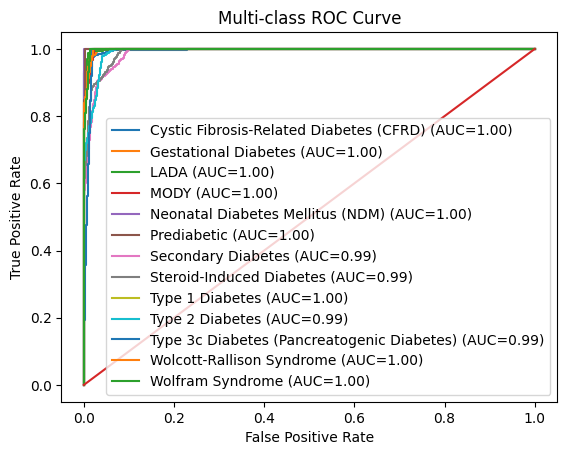

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for i in range(len(le.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()

# **SHAP EXPLAINABILITY FOR STACKING MODEL**

**SHAP ON BASE MODEL (XGBoost)**

Install SHAP

In [ ]:
!pip install shap

In [104]:
import shap


Preprocess data

In [105]:
# Make sure X_train, X_test, preprocessor are already defined
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Convert to DataFrame with feature names for SHAP
feature_names = preprocessor.get_feature_names_out()
X_test_proc_df = pd.DataFrame(X_test_proc, columns=feature_names)
X_test_proc_array = X_test_proc_df.to_numpy()

Create SHAP Explainer

In [106]:
xgb_model = xgb_best.named_steps["model"]  # trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# For multi-class XGBoost, shap_values is a list of arrays (one per class)
shap_values = explainer.shap_values(X_test_proc_array)

# Create output folder for plots
output_dir = "shap_plots"
os.makedirs(output_dir, exist_ok=True)

In [114]:
print(type(shap_values))
if isinstance(shap_values, list):
    print("Number of classes (list length):", len(shap_values))
    print("Shape of first class array:", shap_values[0].shape)
else:
    print("SHAP array shape:", shap_values.shape)  # likely (n_samples, n_features, n_classes)

<class 'numpy.ndarray'>
SHAP array shape: (14000, 58, 13)


Plot SHAP for each class

In [115]:
# If shap_values is 3D: (n_samples, n_features, n_classes)
for i, class_name in enumerate(le.classes_):
    print(f"Generating SHAP plots for class: {class_name}")

    # Beeswarm plot
    plt.figure()
    shap.summary_plot(shap_values[:, :, i], X_test_proc_array, feature_names=feature_names, show=False)
    plt.title(f"SHAP Beeswarm - {class_name}")
    plt.savefig(os.path.join(output_dir, f"shap_beeswarm_{class_name}.png"))
    plt.close()

    # Bar plot
    plt.figure()
    shap.summary_plot(shap_values[:, :, i], X_test_proc_array, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance - {class_name}")
    plt.savefig(os.path.join(output_dir, f"shap_bar_{class_name}.png"))
    plt.close()

Generating SHAP plots for class: Cystic Fibrosis-Related Diabetes (CFRD)
Generating SHAP plots for class: Gestational Diabetes
Generating SHAP plots for class: LADA
Generating SHAP plots for class: MODY
Generating SHAP plots for class: Neonatal Diabetes Mellitus (NDM)
Generating SHAP plots for class: Prediabetic
Generating SHAP plots for class: Secondary Diabetes
Generating SHAP plots for class: Steroid-Induced Diabetes
Generating SHAP plots for class: Type 1 Diabetes
Generating SHAP plots for class: Type 2 Diabetes
Generating SHAP plots for class: Type 3c Diabetes (Pancreatogenic Diabetes)
Generating SHAP plots for class: Wolcott-Rallison Syndrome
Generating SHAP plots for class: Wolfram Syndrome


SHAP-based clustering & t-SNE

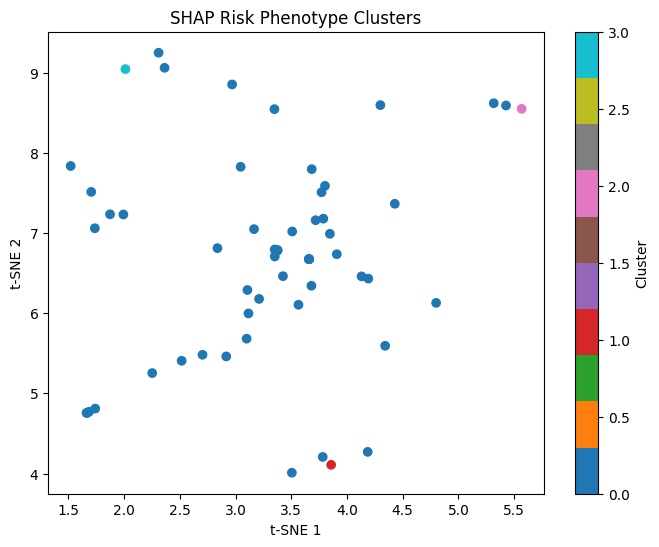

In [111]:
# Use SHAP values of first class for clustering
shap_matrix = np.array(shap_values[0])  # shape: (n_samples, n_features)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(shap_matrix)

# t-SNE embedding
tsne = TSNE(n_components=2, random_state=42)
shap_embedded = tsne.fit_transform(shap_matrix)

plt.figure(figsize=(8,6))
plt.scatter(shap_embedded[:,0], shap_embedded[:,1], c=clusters, cmap='tab10')
plt.title("SHAP Risk Phenotype Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Cluster")
plt.savefig(os.path.join(output_dir, "shap_tsne_clusters.png"))
plt.show()

SHAP for stacking meta-model

In [112]:
meta_X_train = stacking_clf.transform(X_train)
meta_X_test = stacking_clf.transform(X_test)

meta_explainer = shap.LinearExplainer(stacking_clf.final_estimator_, meta_X_train)
meta_shap = meta_explainer.shap_values(meta_X_test)

plt.figure()
shap.summary_plot(meta_shap, meta_X_test, show=False)
plt.title("Meta-model SHAP Feature Importance")
plt.savefig(os.path.join(output_dir, "meta_shap_summary.png"))
plt.close()

<Figure size 640x480 with 0 Axes>

In [116]:
output_dir = "shap_plots"

In [117]:
import os
print(os.getcwd())

/content


List all saved plots

In [118]:
output_dir = "shap_plots"
print("Saved SHAP plots:")
print(os.listdir(output_dir))

Saved SHAP plots:
['shap_bar_LADA.png', 'shap_bar_MODY.png', 'shap_bar_Wolfram Syndrome.png', 'shap_beeswarm_Gestational Diabetes.png', 'shap_bar_Gestational Diabetes.png', 'shap_beeswarm_Neonatal Diabetes Mellitus (NDM).png', 'shap_summary_Prediabetic.png', 'shap_bar_Steroid-Induced Diabetes.png', 'shap_summary_Gestational Diabetes.png', 'shap_beeswarm_LADA.png', 'shap_beeswarm_Wolfram Syndrome.png', 'shap_summary_Type 3c Diabetes (Pancreatogenic Diabetes).png', 'shap_tsne_clusters.png', 'shap_beeswarm_Steroid-Induced Diabetes.png', 'shap_beeswarm_Prediabetic.png', 'shap_summary_Wolcott-Rallison Syndrome.png', 'shap_bar_Secondary Diabetes.png', 'shap_bar_Type 1 Diabetes.png', 'shap_summary_Cystic Fibrosis-Related Diabetes (CFRD).png', 'shap_beeswarm_Secondary Diabetes.png', 'shap_bar_Cystic Fibrosis-Related Diabetes (CFRD).png', 'shap_beeswarm_Type 1 Diabetes.png', 'shap_summary_Neonatal Diabetes Mellitus (NDM).png', 'shap_summary_Secondary Diabetes.png', 'shap_summary_Wolfram Syndrom

Open the plots

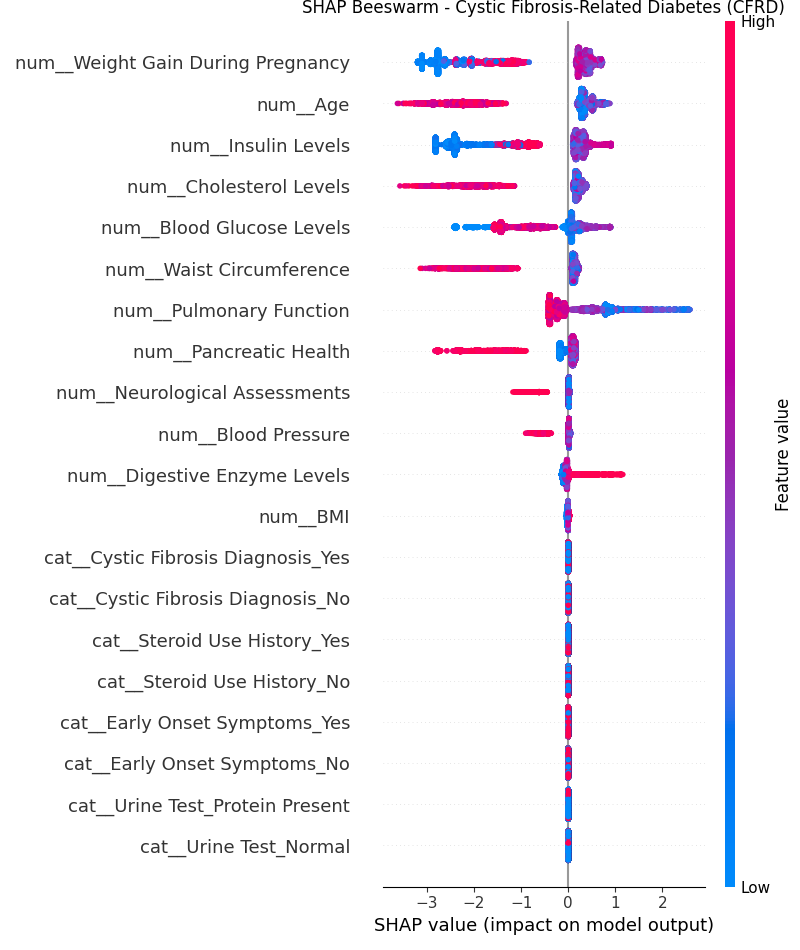

In [119]:
from IPython.display import Image
Image(filename="shap_plots/shap_beeswarm_Cystic Fibrosis-Related Diabetes (CFRD).png")

In [120]:
import os
from IPython.display import Image, display

for file in os.listdir("shap_plots"):
    if file.endswith(".png"):
        display(Image(filename=os.path.join("shap_plots", file)))

Output hidden; open in https://colab.research.google.com to view.

Download the whole folder as a zip

In [121]:
import shutil

# Zip the folder
shutil.make_archive("shap_plots", 'zip', "shap_plots")

'/content/shap_plots.zip'

In [122]:
from google.colab import files
files.download("shap_plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>